## Packages

In [233]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import pandas_datareader.data as web
import re
from arch import arch_model
from typing import Union

# R packages
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri, r, globalenv, default_converter
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.vectors import StrVector

base = importr('base')
methods = importr('methods')
rugarch = importr('rugarch')
rmgarch = importr('rmgarch')

### Data collection & initial visualization

Collect G-SIBs, O-SIIs and MSCI World/Europe Banks data from Data request file.

In [234]:
# Load the Excel file with multiple sheets from the Data folder
excel_file = pd.ExcelFile('./Data GSIBs OSIIs fase 1.xlsx', engine='openpyxl')

# Display the sheet names to understand the structure of the file
print("Sheet names:", excel_file.sheet_names)

# Load all sheets into separate DataFrames
GSIBs = excel_file.parse('G-SIBs')
OSIIs = excel_file.parse('O-SIIs')
GSIBs_prices = excel_file.parse('G-SIBs Price')
GSIBs_equity = excel_file.parse('G-SIBs Marktwaarde')
GSIBs_liabilities = excel_file.parse('G-SIBs Liabilities')
GSIBs_assets = excel_file.parse('G-SIBs Assets')
OSIIs_prices = excel_file.parse('O-SIIs Price')
OSIIs_equity = excel_file.parse('O-SIIs Marktwaarde')
OSIIs_liabilities = excel_file.parse('O-SIIs Liabilities')
OSIIs_assets = excel_file.parse('O-SIIs Assets')
MSCI_indices = excel_file.parse('MSCI Indices')

# Set 'DATE' as the index for prices, equity, and MSCI Indices dataframes
GSIBs_prices.set_index('DATE', inplace=True)
GSIBs_equity.set_index('DATE', inplace=True)
OSIIs_prices.set_index('DATE', inplace=True)
OSIIs_equity.set_index('DATE', inplace=True)
MSCI_indices.set_index('DATE', inplace=True)

# For the sheets with the first column 'PERIOD', convert 'PERIOD' to datetime
def period_to_quarter_end(s: str) -> Union[pd.Timestamp, pd.NaT]:
    """
    Parse strings like 'Q1 2008' → quarter-end timestamp.
    Assumes calendar quarters (Q-DEC). If your data uses fiscal quarters,
    adjust freq (e.g., 'Q-MAR' or 'Q-JUN').
    """
    if not isinstance(s, str):
        return pd.NaT
    m = re.match(r'^Q([1-4])\s+(\d{4})$', s.strip())
    if not m:
        return pd.NaT
    q = int(m.group(1))
    y = int(m.group(2))
    # Calendar year with quarter ending in Dec (Mar/Jun/Sep/Dec quarters):
    p = pd.Period(f'{y}Q{q}', freq='Q-DEC')
    return p.to_timestamp(how='end')  # quarter end (e.g., 2008-03-31)

# Apply the conversion to the 'PERIOD' column and set it as the index for liabilities and assets dataframes
GSIBs_liabilities['PERIOD'] = GSIBs_liabilities['PERIOD'].apply(period_to_quarter_end)
GSIBs_liabilities.set_index('PERIOD', inplace=True)

GSIBs_assets['PERIOD'] = GSIBs_assets['PERIOD'].apply(period_to_quarter_end)
GSIBs_assets.set_index('PERIOD', inplace=True)

OSIIs_liabilities['PERIOD'] = OSIIs_liabilities['PERIOD'].apply(period_to_quarter_end)
OSIIs_liabilities.set_index('PERIOD', inplace=True)

OSIIs_assets['PERIOD'] = OSIIs_assets['PERIOD'].apply(period_to_quarter_end)
OSIIs_assets.set_index('PERIOD', inplace=True)

# Convert liabilities and assets from thousands to millions to match equity values
for df_name in ["GSIBs_liabilities", "GSIBs_assets", "OSIIs_liabilities", "OSIIs_assets"]:
    df = globals()[df_name]

    # ensure numeric where possible; non-numeric becomes NaN
    df = df.apply(pd.to_numeric, errors="coerce") / 1000

    globals()[df_name] = df

# Convert prices for UK banks from GBp to GBP by dividing by 100, banks in columns 14, 15, and 16
GSIBs_prices.iloc[:, 13:16] = GSIBs_prices.iloc[:, 13:16] / 100

# Reverse the dataframes to have the most recent dates first
GSIBs = GSIBs.iloc[::-1]
OSIIs = OSIIs.iloc[::-1]
GSIBs_prices = GSIBs_prices.iloc[::-1]
GSIBs_equity = GSIBs_equity.iloc[::-1]
GSIBs_liabilities = GSIBs_liabilities.iloc[::-1]
GSIBs_assets = GSIBs_assets.iloc[::-1]
OSIIs_prices = OSIIs_prices.iloc[::-1]
OSIIs_equity = OSIIs_equity.iloc[::-1]
OSIIs_liabilities = OSIIs_liabilities.iloc[::-1]
OSIIs_assets = OSIIs_assets.iloc[::-1]
MSCI_indices = MSCI_indices.iloc[::-1]

# Display the first few rows and columns of the GSIBs_prices dataframe
print("GSIBs_prices DataFrame (first 5 rows and columns):")
print(GSIBs_prices.iloc[:5, :5])

Sheet names: ['G-SIBs', 'O-SIIs', 'G-SIBs Price', 'G-SIBs Marktwaarde', 'G-SIBs Liabilities', 'G-SIBs Assets', 'O-SIIs Price', 'O-SIIs Marktwaarde', 'O-SIIs Liabilities', 'O-SIIs Assets', 'MSCI Indices']
GSIBs_prices DataFrame (first 5 rows and columns):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  \
DATE                                                            
2025-11-07                204.01            113.58      30.35   
2025-11-06                205.25            113.54      30.78   
2025-11-05                205.64            113.85      31.18   
2025-11-04                205.40            113.56      30.54   
2025-11-03                207.22            115.18      30.63   

            AGRICULTURAL BK.OF CHIN  BANK OF CHINA  
DATE                                                
2025-11-07                     6.09           4.58  
2025-11-06                     6.08           4.57  
2025-11-05                     6.11           4.53  
2025-11-04              

Visualize some of the data, specifically 10 relevant G-SIBs 

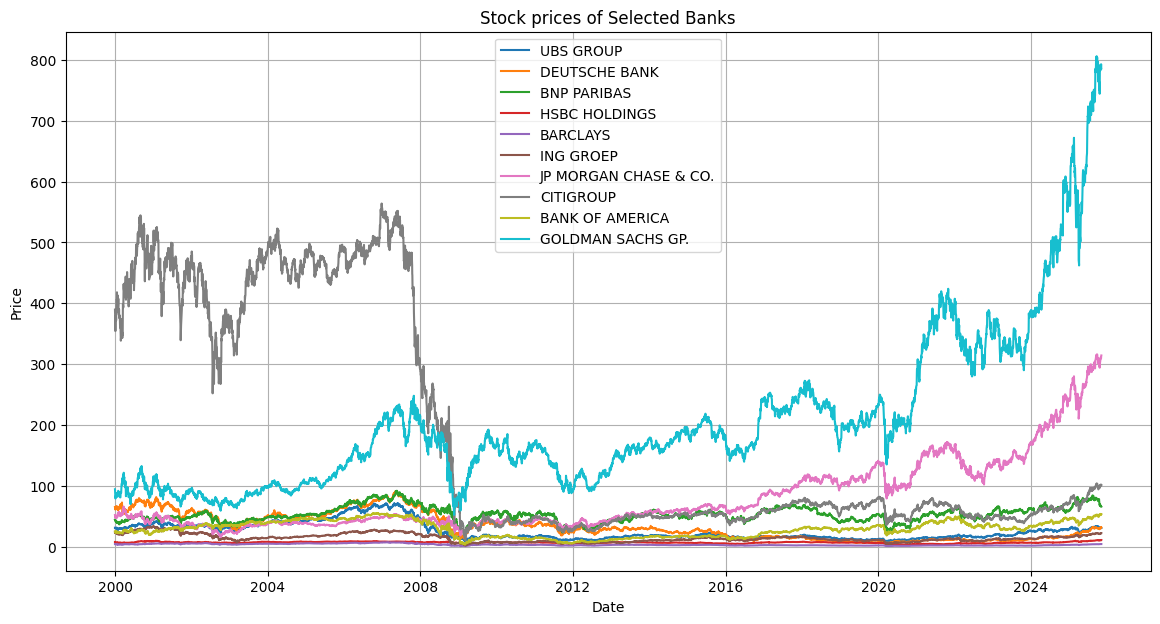

In [235]:
# Plot the banks in the specified columns
columns_to_plot = [2, 8, 10, 13, 14, 19, 20, 21, 22, 23]  # 0-based indexing
plt.figure(figsize=(14, 7))
for col in columns_to_plot:
    plt.plot(GSIBs_prices.index, GSIBs_prices.iloc[:, col], label=GSIBs_prices.columns[col])
plt.title('Stock prices of Selected Banks')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

### Data processing

Omit missing values and/or certain timeframes 

In [236]:
price_cols = set(GSIBs_prices.columns)

print("Missing in equity:", sorted(price_cols - set(GSIBs_equity.columns))[:50])
print("Missing in liabilities:", sorted(price_cols - set(GSIBs_liabilities.columns))[:50])

print("Extra in equity:", sorted(set(GSIBs_equity.columns) - price_cols)[:50])
print("Extra in liabilities:", sorted(set(GSIBs_liabilities.columns) - price_cols)[:50])



Missing in equity: []
Missing in liabilities: []
Extra in equity: []
Extra in liabilities: []


In [237]:
# Exclude GSIBs where the first observation is after 2008-01-01 or contains #N/A after 2008-01-01
initial_date = pd.Timestamp('2008-01-01')

# Replace '#N/A' with NaN for proper handling
GSIBs_prices.replace('#N/A', np.nan, inplace=True)

# Identify columns with #N/A (now NaN) after the initial_date
columns_with_na_after_date = GSIBs_prices.loc[GSIBs_prices.index > initial_date].isna().any()

# Exclude columns with #N/A after the initial_date
GSIBs_prices_omitted = GSIBs_prices.loc[:, ~columns_with_na_after_date]

# Omit the rows with any missing values across the GSIBs_prices_omitted dataframe
GSIBs_prices = GSIBs_prices_omitted.dropna(axis=0, how='any')

# Show the row numbers that were dropped
dropped_rows = GSIBs_prices_omitted.index.difference(GSIBs_prices.index)
print("Dropped row indices due to missing values:")
print(dropped_rows)

# Make sure the same columns are dropped from the related equity and liabilities dataframes
GSIBs_equity = GSIBs_equity[GSIBs_prices.columns]
GSIBs_liabilities = GSIBs_liabilities[GSIBs_prices.columns]

Dropped row indices due to missing values:
DatetimeIndex(['1999-12-31', '2000-01-03', '2000-01-04', '2000-01-05',
               '2000-01-06', '2000-01-07', '2000-01-10', '2000-01-11',
               '2000-01-12', '2000-01-13',
               ...
               '2006-10-13', '2006-10-16', '2006-10-17', '2006-10-18',
               '2006-10-19', '2006-10-20', '2006-10-23', '2006-10-24',
               '2006-10-25', '2006-10-26'],
              dtype='datetime64[ns]', name='DATE', length=1780, freq=None)


Add the MSCI World Banks Index to the start of the G-SIBs dataframe

In [238]:
# Extract the MSCI World index from the MSCI_indices dataframe
MSCI_World = MSCI_indices.iloc[:, 1] # Assuming the second column is MSCI World

# Drop the same rows from MSCI_World to align with GSIBs_prices
MSCI_World = MSCI_World.drop(index=dropped_rows)

# Verify alignment
assert GSIBs_prices.index.equals(MSCI_World.index), "Indices are not aligned!"
print("Indices are aligned after dropping rows.")

# Add MSCI_World to the first column of the GSIBs_prices dataframe if it doesn't already exist
if 'MSCI World' not in GSIBs_prices.columns:
    GSIBs_prices.insert(0, 'MSCI World', MSCI_World)

# Display the first few rows and columns of the cleaned GSIBs_prices dataframe
print("Cleaned GSIBs_prices DataFrame (first 10 rows and 4 columns):")
print(GSIBs_prices.iloc[:10, :4])

Indices are aligned after dropping rows.
Cleaned GSIBs_prices DataFrame (first 10 rows and 4 columns):
            MSCI World  ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP
DATE                                                                     
2025-11-07     179.739                204.01            113.58      30.35
2025-11-06     180.344                205.25            113.54      30.78
2025-11-05     179.481                205.64            113.85      31.18
2025-11-04     179.375                205.40            113.56      30.54
2025-11-03     179.593                207.22            115.18      30.63
2025-10-31     179.142                205.47            115.16      30.73
2025-10-30     178.327                204.12            114.64      30.68
2025-10-29     177.527                204.55            114.03      30.60
2025-10-28     177.722                207.80            115.29      30.92
2025-10-27     176.890                207.45            114.26      30.74


Compute returns

In [239]:
# Function to calculate percentage log returns for all columns in a DataFrame
def calculate_log_returns(df):
    return 100 * np.log(df / df.shift(1)).dropna()

# Calculate log returns for GSIBs and OSIIs including the MSCI indices
gsibs_returns = calculate_log_returns(GSIBs_prices)
osiis_returns = calculate_log_returns(OSIIs_prices)

Visualize some log returns

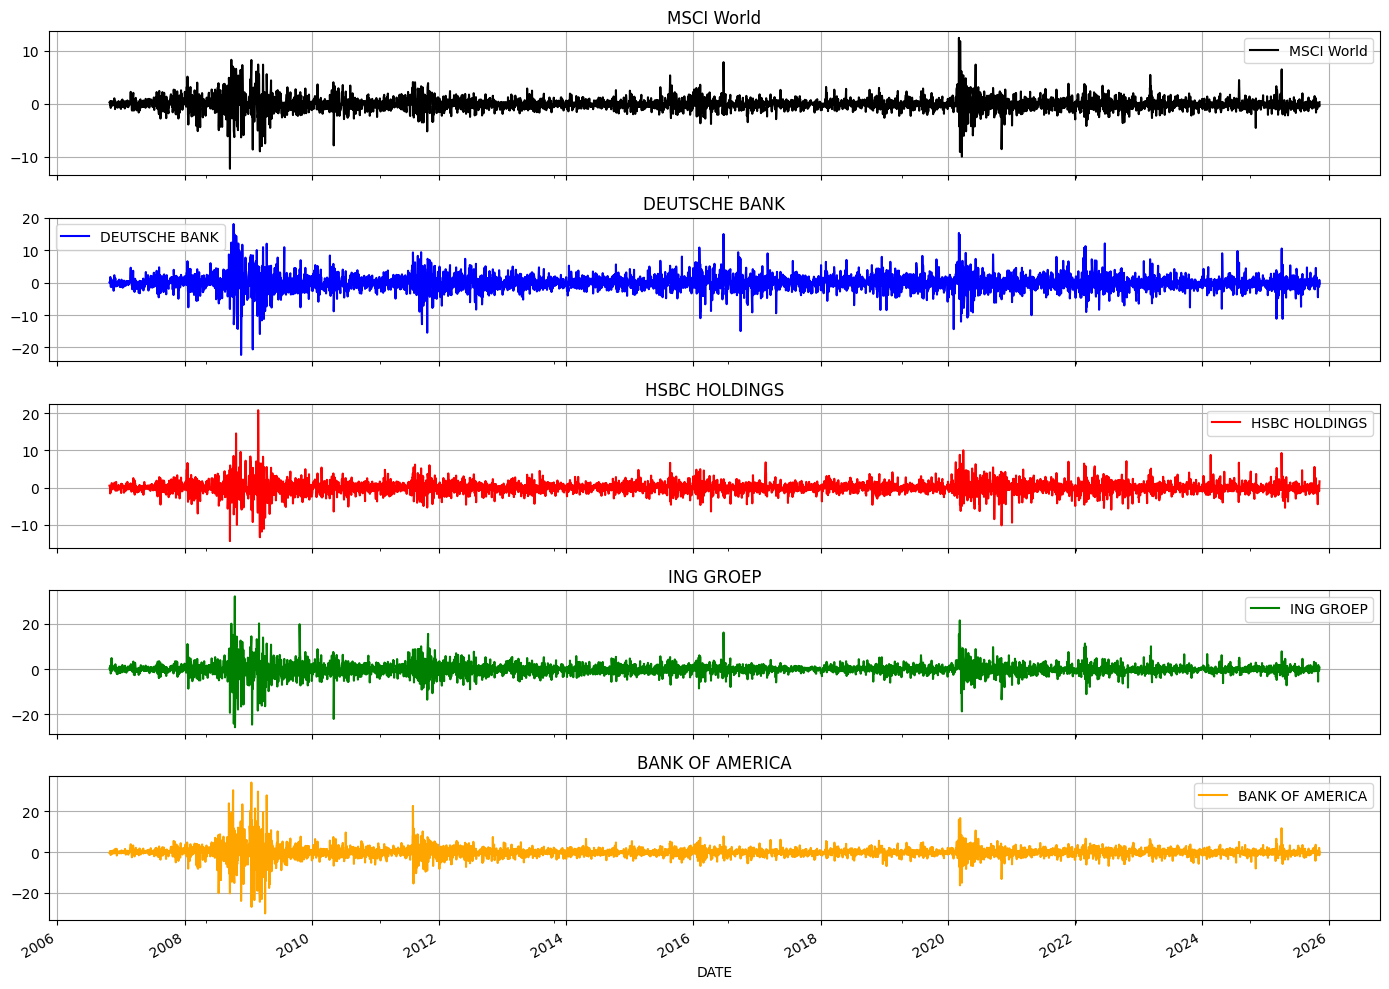

In [240]:
# Select the specified columns from gsibs_returns
columns_to_plot = [0, 8, 13, 19, 22]
selected_returns = gsibs_returns.iloc[:, columns_to_plot]

# Plot the log returns of the selected columns
selected_returns.plot(subplots=True, layout=(5, 1), figsize=(14, 10), color=['black', 'blue', 'red', 'green', 'orange'], 
                      title=selected_returns.columns.tolist(), legend=True, grid=True)
plt.tight_layout()
plt.show()


### Univariate GARCH(1,1) model fitting

Using the Python arch package

In [241]:
# Create an empty DataFrame to store conditional variances
cond_var_df_gsibs = pd.DataFrame(index=gsibs_returns.index, columns=gsibs_returns.columns)

# Fit GARCH(1,1) model for each asset in gsibs_returns and store conditional variances
for asset in gsibs_returns.columns:
    model = arch_model(gsibs_returns[asset], vol='GARCH', p=1, q=1, mean='Constant', dist='normal')
    res = model.fit(disp='off')
    cond_var_df_gsibs[asset] = res.conditional_volatility ** 2

# Display the first 10 rows and 4 columns of the conditional variance DataFrame
print("Conditional Variances for GSIBs - Python arch package (first 10 rows and 4 columns):")
print(cond_var_df_gsibs.iloc[:10, :4])

Conditional Variances for GSIBs - Python arch package (first 10 rows and 4 columns):
            MSCI World  ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP
DATE                                                                     
2025-11-06    0.383697              0.524262          0.762747   1.455213
2025-11-05    0.376231              0.536798          0.652791   1.584832
2025-11-04    0.374052              0.498647          0.588066   1.668507
2025-11-03    0.345458              0.459018          0.524058   1.977950
2025-10-31    0.326228              0.538608          0.886979   1.858413
2025-10-30    0.311277              0.573241          0.749861   1.755192
2025-10-29    0.316949              0.568567          0.672841   1.654270
2025-10-28    0.320930              0.526897          0.626438   1.568910
2025-10-27    0.305170              0.826286          0.805176   1.597247
2025-10-24    0.313458              0.737464          0.822251   1.543232


Using R rugarch package

In [242]:
# Fit GARCH(1,1) model using rugarch for gsibs_returns and store results
rugarch_models_gsibs = {}
cond_var_r_df_gsibs = pd.DataFrame(index=gsibs_returns.index, columns=gsibs_returns.columns)

for asset in gsibs_returns.columns:
    with localconverter(ro.default_converter + pandas2ri.converter):
        returns_r = ro.conversion.py2rpy(gsibs_returns[asset].dropna())
    spec = rugarch.ugarchspec(
        variance_model=ro.ListVector({'model': 'sGARCH', 'garchOrder': ro.IntVector([1, 1]), 'variance.targeting': False}),
        mean_model=ro.ListVector({'armaOrder': ro.IntVector([0, 0]), 'include.mean': True}),
        distribution_model='norm'
    )
    fit = rugarch.ugarchfit(spec, returns_r, solver='hybrid')
    rugarch_models_gsibs[asset] = fit
    cond_var_r_df_gsibs.loc[gsibs_returns[asset].dropna().index, asset] = np.array(rugarch.sigma(fit)).flatten()[::-1] ** 2

# Display the first 10 rows and 4 columns of the conditional variance DataFrame
print("Conditional Variances for GSIBs - R rugarch package (first 10 rows and 4 columns):")
print(cond_var_r_df_gsibs.iloc[:10, :4])

Conditional Variances for GSIBs - R rugarch package (first 10 rows and 4 columns):
           MSCI World ROYAL BANK OF CANADA TORONTO DOMINION UBS GROUP
DATE                                                                 
2025-11-06    0.44875             0.602194         0.803327  1.961189
2025-11-05   0.458612             0.651704         0.857651  1.921007
2025-11-04   0.494786             0.715083         0.923457  1.632587
2025-11-03   0.532648             0.680009          0.79511  1.708474
2025-10-31   0.575212             0.668459          0.85819  1.791699
2025-10-30   0.607842             0.688433         0.912335  1.894616
2025-10-29   0.646347             0.749361         0.965463  2.006526
2025-10-28   0.708829             0.497666         0.921364  2.029451
2025-10-27   0.761223              0.53715         0.928571  2.132699
2025-10-24   0.735636             0.578129         0.951682  2.156664


Compare the conditional variances from Python and R

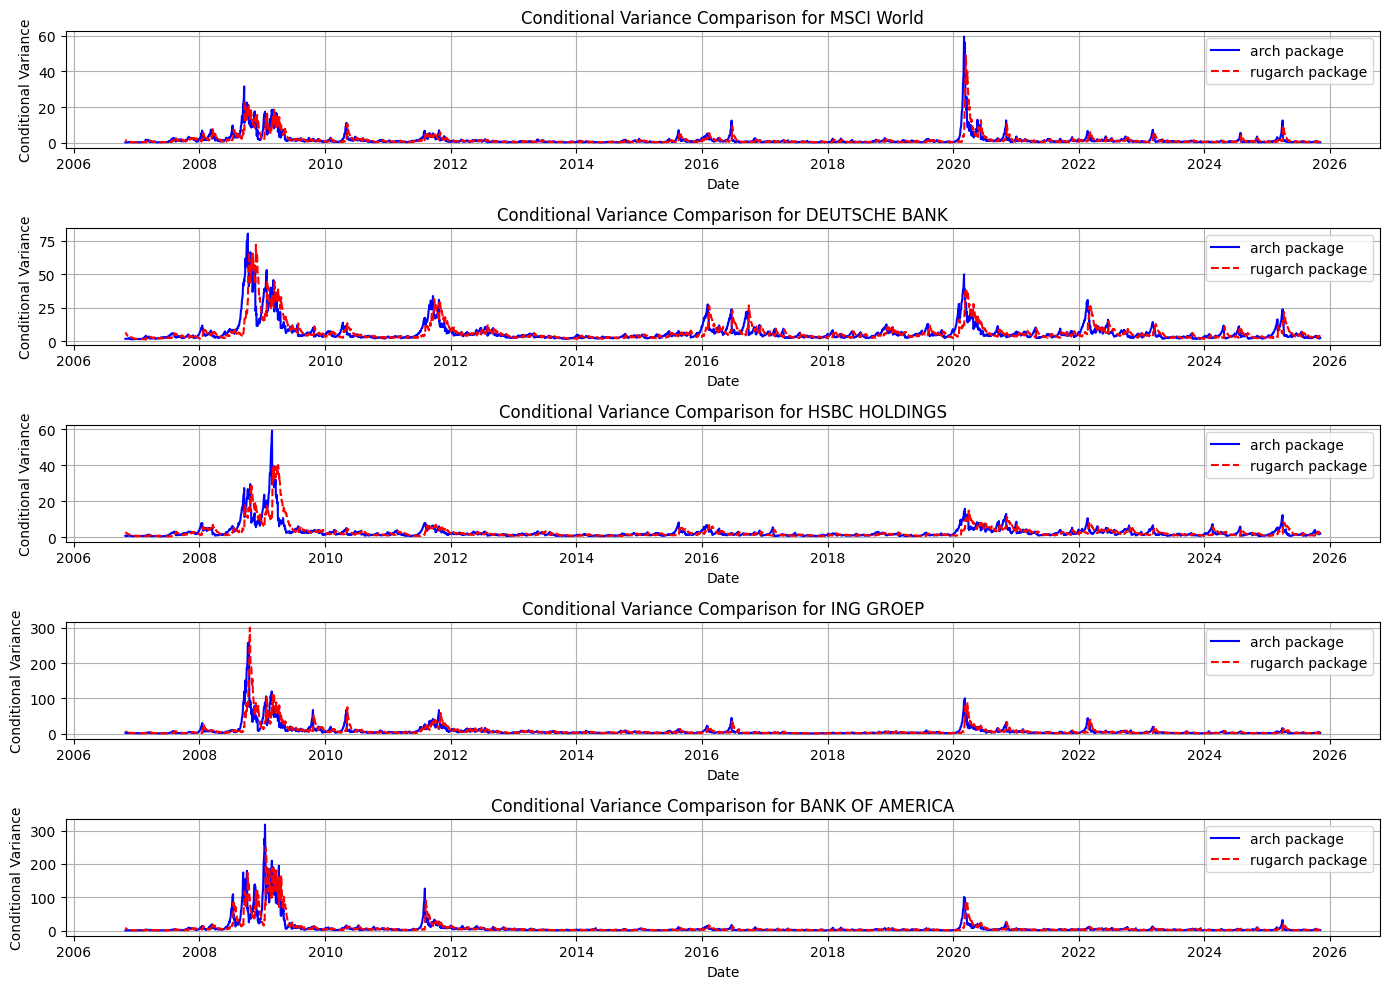

Correlation of conditional variances for MSCI World: 0.6266
Correlation of conditional variances for DEUTSCHE BANK: 0.6708
Correlation of conditional variances for HSBC HOLDINGS: 0.6500
Correlation of conditional variances for ING GROEP: 0.6460
Correlation of conditional variances for BANK OF AMERICA: 0.7261


In [243]:
# Define the columns to plot
columns_to_plot = [0, 8, 13, 19, 22]  # Adjusted for gsibs_returns

# Compare the conditional variances from arch and rugarch for the selected columns
plt.figure(figsize=(14, 10))
for i, col in enumerate(columns_to_plot, 1):
    asset = gsibs_returns.columns[col]
    plt.subplot(len(columns_to_plot), 1, i)
    plt.plot(cond_var_df_gsibs[asset], label='arch package', color='blue')
    plt.plot(cond_var_r_df_gsibs[asset], label='rugarch package', color='red', linestyle='--')
    plt.title(f'Conditional Variance Comparison for {asset}')
    plt.xlabel('Date')
    plt.ylabel('Conditional Variance')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

# Compare how much the conditional variances correlate for the selected columns
for col in columns_to_plot:
    asset = gsibs_returns.columns[col]
    corr = cond_var_df_gsibs[asset].corr(cond_var_r_df_gsibs[asset])
    print(f'Correlation of conditional variances for {asset}: {corr:.4f}')


Compute the diagonal matrix of conditional standard deviations $D_t$

In [244]:
# Calculate D matrices for the entire cond_var_r_df_gsibs dataframe
# Ensure all columns in cond_var_r_df_gsibs are numeric
cond_var_r_df_gsibs = cond_var_r_df_gsibs.apply(pd.to_numeric, errors='coerce')

# Calculate D matrices
gsibs_D_matrices = {date: np.diag(np.sqrt(cond_var_r_df_gsibs.loc[date])) for date in cond_var_r_df_gsibs.index}

# Flatten D matrices into a DataFrame for CSV export
gsibs_D_df = pd.DataFrame({
    'Date': cond_var_r_df_gsibs.index,
    **{f'D_{i+1}{i+1}': [gsibs_D_matrices[date][i, i] for date in cond_var_r_df_gsibs.index] for i in range(cond_var_r_df_gsibs.shape[1])}
}).set_index('Date')

# Save the D matrices to a CSV file
print("D Matrices DataFrame (first 5 rows):\n", gsibs_D_df.head())


D Matrices DataFrame (first 5 rows):
                 D_11      D_22      D_33      D_44      D_55      D_66  \
Date                                                                     
2025-11-06  0.669888  0.776012  0.896285  1.400425  1.206284  1.462367   
2025-11-05  0.677209  0.807282  0.926094  1.386004  1.214994  1.453040   
2025-11-04  0.703410  0.845626  0.960967  1.277727  1.256730  1.488602   
2025-11-03  0.729827  0.824627  0.891689  1.307086  1.303426  1.489269   
2025-10-31  0.758427  0.817593  0.926385  1.338544  1.079463  1.308948   

                D_77      D_88      D_99    D_1010  ...    D_1919    D_2020  \
Date                                                ...                       
2025-11-06  1.296494  1.199363  1.795396  1.685711  ...  1.791339  1.766210   
2025-11-05  1.301802  1.215454  1.829917  1.757871  ...  1.585726  1.863985   
2025-11-04  1.329089  1.233258  1.851280  1.834822  ...  1.531259  1.961565   
2025-11-03  1.328658  1.224932  1.900266  1.9308

### DCC estimation

To compute the time-varying conditional correlation matrix we use the DCC approach introduced by Engle (2002)

In [245]:
# Convert gsibs_returns dataframe to R
with localconverter(ro.default_converter + pandas2ri.converter):
    gsibs_returns_r = ro.conversion.py2rpy(gsibs_returns.dropna())

# Define univariate GARCH specs for each asset in gsibs_returns using rugarch
gsibs_uspec = rugarch.multispec([
    rugarch.ugarchspec(
        variance_model=ro.ListVector({'model': 'sGARCH', 'garchOrder': ro.IntVector([1, 1])}),
        mean_model=ro.ListVector({'armaOrder': ro.IntVector([0, 0]), 'include.mean': True}),
        distribution_model='norm'
    ) for _ in range(gsibs_returns.shape[1])
])

# Define DCC spec for gsibs_returns
gsibs_dcc_spec = rmgarch.dccspec(uspec=gsibs_uspec, dccOrder=ro.IntVector([1, 1]), distribution='mvnorm')

# Fit the DCC model for gsibs_returns
gsibs_dcc_fit = rmgarch.dccfit(gsibs_dcc_spec, data=gsibs_returns_r)

# Extract R_t matrices for gsibs_returns
gsibs_Rt_array = rmgarch.rcor(gsibs_dcc_fit)

# Convert the full 3D array from R to NumPy for gsibs_returns
with localconverter(default_converter + numpy2ri.converter):
    gsibs_Rt_array_np = ro.conversion.rpy2py(gsibs_Rt_array)

# Create a DataFrame to store the R matrices for gsibs_returns
gsibs_R_matrices = {date: gsibs_Rt_array_np[:, :, i] for i, date in enumerate(gsibs_returns.index)}

# Flatten the R matrices into a DataFrame for CSV export
gsibs_R_df = pd.DataFrame({
    'Date': gsibs_returns.index,
    **{f'R_{row+1}{col+1}': [gsibs_R_matrices[date][row, col] for date in gsibs_returns.index] for row in range(gsibs_Rt_array_np.shape[0]) for col in range(gsibs_Rt_array_np.shape[1])}
}).set_index('Date')

# Save the R matrices for gsibs_returns to a CSV file
print("R Matrices DataFrame for gsibs_returns:\n", gsibs_R_df.head().to_string())

R Matrices DataFrame for gsibs_returns:
             R_11      R_12      R_13      R_14      R_15      R_16      R_17      R_18      R_19     R_110     R_111     R_112     R_113     R_114     R_115     R_116     R_117     R_118     R_119     R_120     R_121     R_122     R_123     R_124     R_125     R_126     R_127     R_128      R_21  R_22      R_23      R_24      R_25      R_26      R_27      R_28      R_29     R_210     R_211     R_212     R_213     R_214     R_215     R_216     R_217     R_218     R_219     R_220     R_221     R_222     R_223     R_224     R_225     R_226     R_227     R_228      R_31      R_32  R_33      R_34      R_35      R_36      R_37      R_38      R_39     R_310     R_311     R_312     R_313     R_314     R_315     R_316     R_317     R_318     R_319     R_320     R_321     R_322     R_323     R_324     R_325     R_326     R_327     R_328      R_41      R_42      R_43  R_44      R_45      R_46      R_47      R_48      R_49     R_410     R_411     R_412     

Next, we compute the time-varying conditional covariance matrix $H_t$ decomposed as $H_t = D_t R_t D_t$.

In [246]:
# Compute matrices H_t = D_t * R_t * D_t for G-SIBs and save to CSV
gsibs_H_matrices = {}
for date in gsibs_returns.index:
    D_t = gsibs_D_matrices[date]
    R_t = gsibs_R_matrices[date]
    H_t = D_t @ R_t @ D_t
    gsibs_H_matrices[date] = H_t

# Flatten H matrices into a DataFrame for CSV export
gsibs_H_df = pd.DataFrame({
    'Date': gsibs_returns.index,
    **{f'H_{row+1}{col+1}': [gsibs_H_matrices[date][row, col] for date in gsibs_returns.index] for row in range(gsibs_Rt_array_np.shape[0]) for col in range(gsibs_Rt_array_np.shape[1])}
}).set_index('Date')

# Save the H matrices for G-SIBs to a CSV file
print("H Matrices DataFrame for G-SIBs:\n", gsibs_H_df.head().to_string())

H Matrices DataFrame for G-SIBs:
                 H_11      H_12      H_13      H_14      H_15      H_16      H_17      H_18      H_19     H_110     H_111     H_112     H_113     H_114     H_115     H_116     H_117     H_118     H_119     H_120     H_121     H_122     H_123     H_124     H_125     H_126     H_127     H_128      H_21      H_22      H_23      H_24      H_25      H_26      H_27      H_28      H_29     H_210     H_211     H_212     H_213     H_214     H_215     H_216     H_217     H_218     H_219     H_220     H_221     H_222     H_223     H_224     H_225     H_226     H_227     H_228      H_31      H_32      H_33      H_34      H_35      H_36      H_37      H_38      H_39     H_310     H_311     H_312     H_313     H_314     H_315     H_316     H_317     H_318     H_319     H_320     H_321     H_322     H_323     H_324     H_325     H_326     H_327     H_328      H_41      H_42      H_43      H_44      H_45      H_46      H_47      H_48      H_49     H_410     H_411     H

### Time-varying Betas

The conditional beta of asset i with respect to the market at time t is defined as: $\beta_{i,t} = \frac{Cov_t(r_{i,t}, r_{m,t})}{Var_t(r_{m,t})} = \frac{h_{im,t}}{h_{m,t}}$ where $h_{im,t}$ is the (i, m)-th element of the conditional covariance matrix $H_t$.

In [247]:
# Initialize list to store H_t matrices for G-SIBs
gsibs_Ht_list = [gsibs_H_matrices[date] for date in gsibs_H_matrices.keys()]

# Compute conditional betas for G-SIBs: beta_{i,t} = h_{im,t} / h_{m,t}
gsibs_market_index = 0
gsibs_bank_indices = list(range(1, len(gsibs_returns.columns)))  # Exclude the market index
gsibs_bank_names = gsibs_returns.columns[1:]  # Exclude the market column

gsibs_beta_df = pd.DataFrame(index=gsibs_returns.index, columns=gsibs_bank_names)

for t, H_t in enumerate(gsibs_Ht_list):
    h_mm_t = H_t[gsibs_market_index, gsibs_market_index]
    for i, bank_idx in enumerate(gsibs_bank_indices):
        h_im_t = H_t[bank_idx, gsibs_market_index]
        gsibs_beta_df.iloc[t, i] = h_im_t / h_mm_t if h_mm_t != 0 else np.nan

# Convert to float
gsibs_beta_df = gsibs_beta_df.astype(float)

Plot the dynamic betas

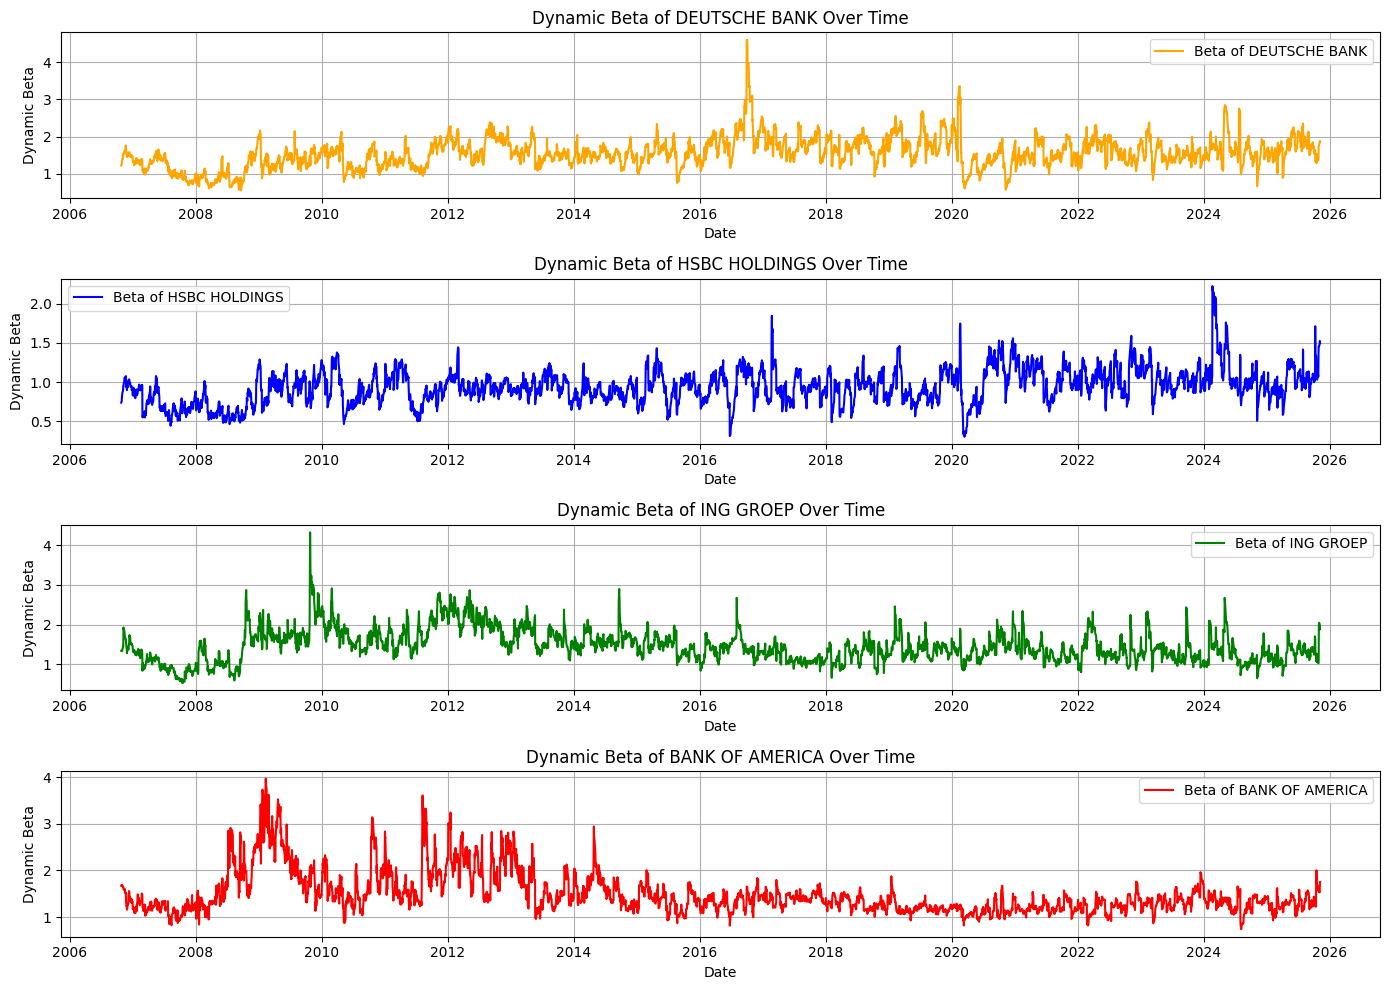

In [248]:
# Select the columns to plot selected bank betas
columns_to_plot = [7, 12, 18, 21]  # Adjusted for 0-based indexing
selected_banks = gsibs_beta_df.columns[columns_to_plot]

# Plot the conditional betas over time for the selected banks
plt.figure(figsize=(14, 10))
for i, bank in enumerate(selected_banks, 1):
    plt.subplot(4, 1, i)
    plt.plot(gsibs_beta_df.index, gsibs_beta_df[bank], label=f'Beta of {bank}', color=['orange', 'blue', 'green', 'red'][i-1])
    plt.title(f'Dynamic Beta of {bank} Over Time')
    plt.xlabel('Date')
    plt.ylabel('Dynamic Beta')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

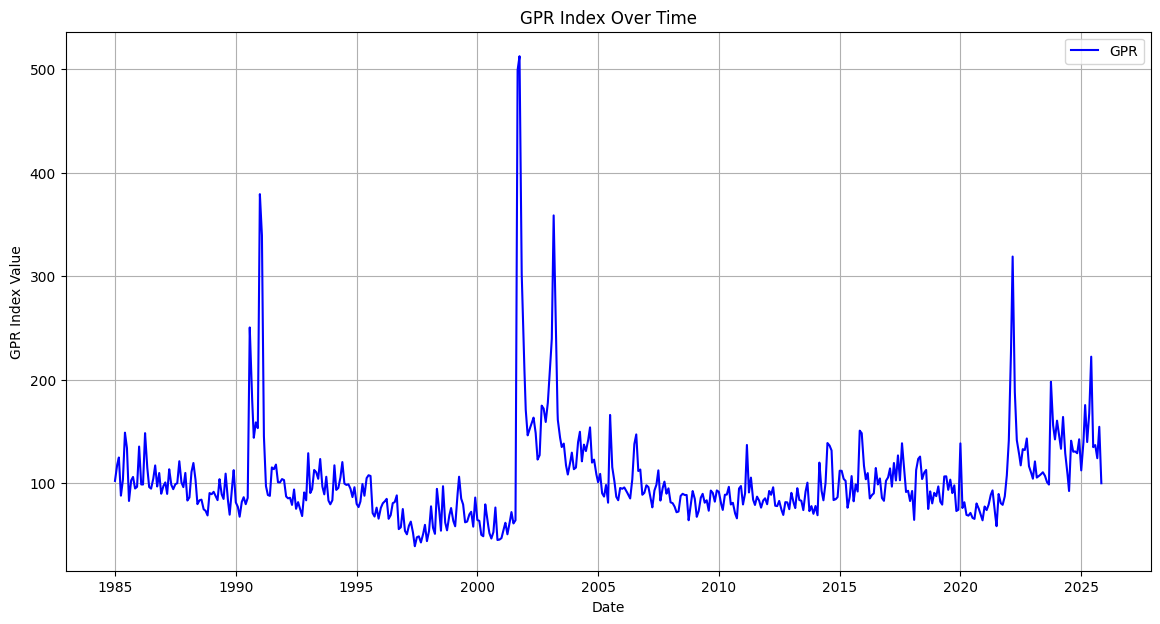

GPR Index Data:
                   GPR
DATE                  
1985-01-01  102.170000
1985-01-02  102.651613
1985-01-03  103.133226
1985-01-04  103.614839
1985-01-05  104.096452
...                ...
2025-10-28  106.946129
2025-10-29  105.187097
2025-10-30  103.428065
2025-10-31  101.669032
2025-11-01   99.910000

[14915 rows x 1 columns]


In [249]:
# Load the GPR index data
gpr_data = pd.read_excel('./gpr_index_data.xlsx', engine='openpyxl')

# Convert 'DATE' column from yyyy-dd-mm to yyyy-mm-dd and set as index
gpr_data['DATE'] = pd.to_datetime(gpr_data['DATE'], format='%Y-%d-%m', errors='coerce', dayfirst=True)
gpr_data.dropna(subset=['DATE'], inplace=True)  # Drop rows where 'DATE' could not be converted
gpr_data.set_index('DATE', inplace=True)

# Resample the data to ensure consistent frequency (e.g., daily) and fill missing values
gpr_data = gpr_data.resample('D').interpolate(method='linear')

# Plot all of the GPR data
plt.figure(figsize=(14, 7))
plt.plot(gpr_data.index, gpr_data.iloc[:, 0], label=gpr_data.columns[0], color='blue')
plt.title('GPR Index Over Time')
plt.xlabel('Date')
plt.ylabel('GPR Index Value')
plt.legend()
plt.grid()
plt.show()

# Print all GPR data
print("GPR Index Data:")
print(gpr_data)

Plot the GPR index into the conditional betas

GPR Index Data (first 5 rows):
                  GPR
DATE                 
2006-10-27  92.709032
2006-10-28  91.923226
2006-10-29  91.137419
2006-10-30  90.351613
2006-10-31  89.565806
2006-11-01  88.780000
2006-11-02  88.841000
2006-11-03  88.902000
2006-11-04  88.963000
2006-11-05  89.024000


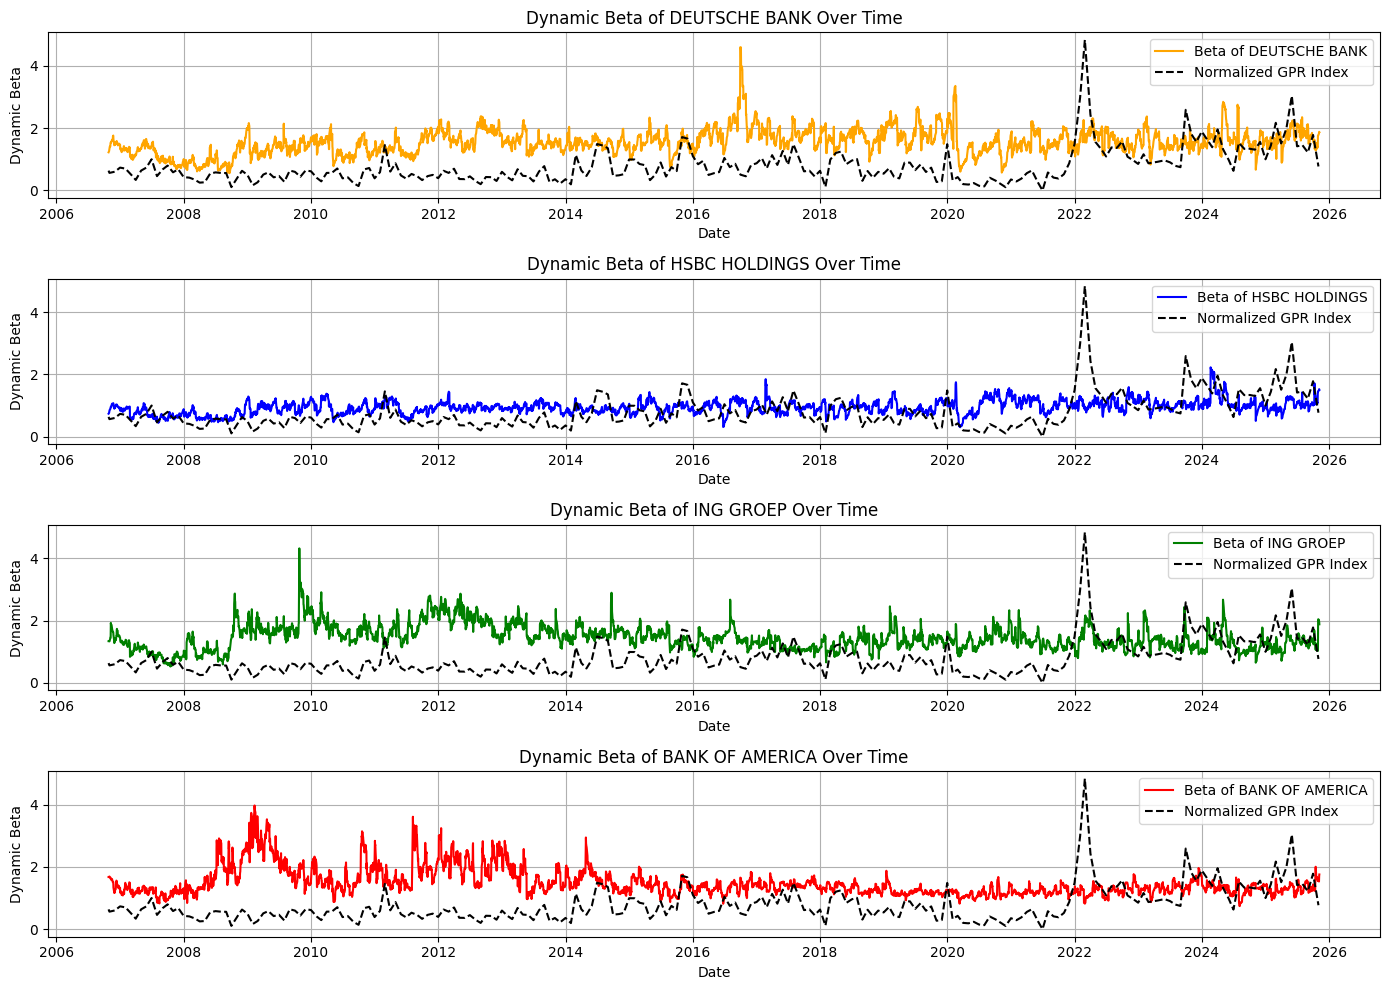

In [250]:
# Ensure no dates fall outside of the range of gsibs_returns
gpr_data = gpr_data[(gpr_data.index >= gsibs_returns.index.min()) & (gpr_data.index <= gsibs_returns.index.max())]

# Print the first few rows of the GPR data
print("GPR Index Data (first 5 rows):")
print(gpr_data.head(10))

# Select the columns to plot selected bank betas
columns_to_plot = [7, 12, 18, 21]  # Adjusted for 0-based indexing
selected_banks = gsibs_beta_df.columns[columns_to_plot]

# Normalize the GPR index to match the range of the betas
gpr_data_normalized = (gpr_data['GPR'] - gpr_data['GPR'].min()) / (gpr_data['GPR'].max() - gpr_data['GPR'].min())
gpr_data_normalized *= (gsibs_beta_df.max().max() - gsibs_beta_df.min().min())

# Plot the conditional betas over time for the selected banks
plt.figure(figsize=(14, 10))
for i, bank in enumerate(selected_banks, 1):
    plt.subplot(len(selected_banks), 1, i)
    plt.plot(gsibs_beta_df.index, gsibs_beta_df[bank], label=f'Beta of {bank}', color=['orange', 'blue', 'green', 'red'][i-1])
    
    # Plot the normalized GPR index on the same subplot
    plt.plot(gpr_data.index, gpr_data_normalized, label='Normalized GPR Index', color='black', linestyle='--')
    
    plt.title(f'Dynamic Beta of {bank} Over Time')
    plt.xlabel('Date')
    plt.ylabel('Dynamic Beta')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

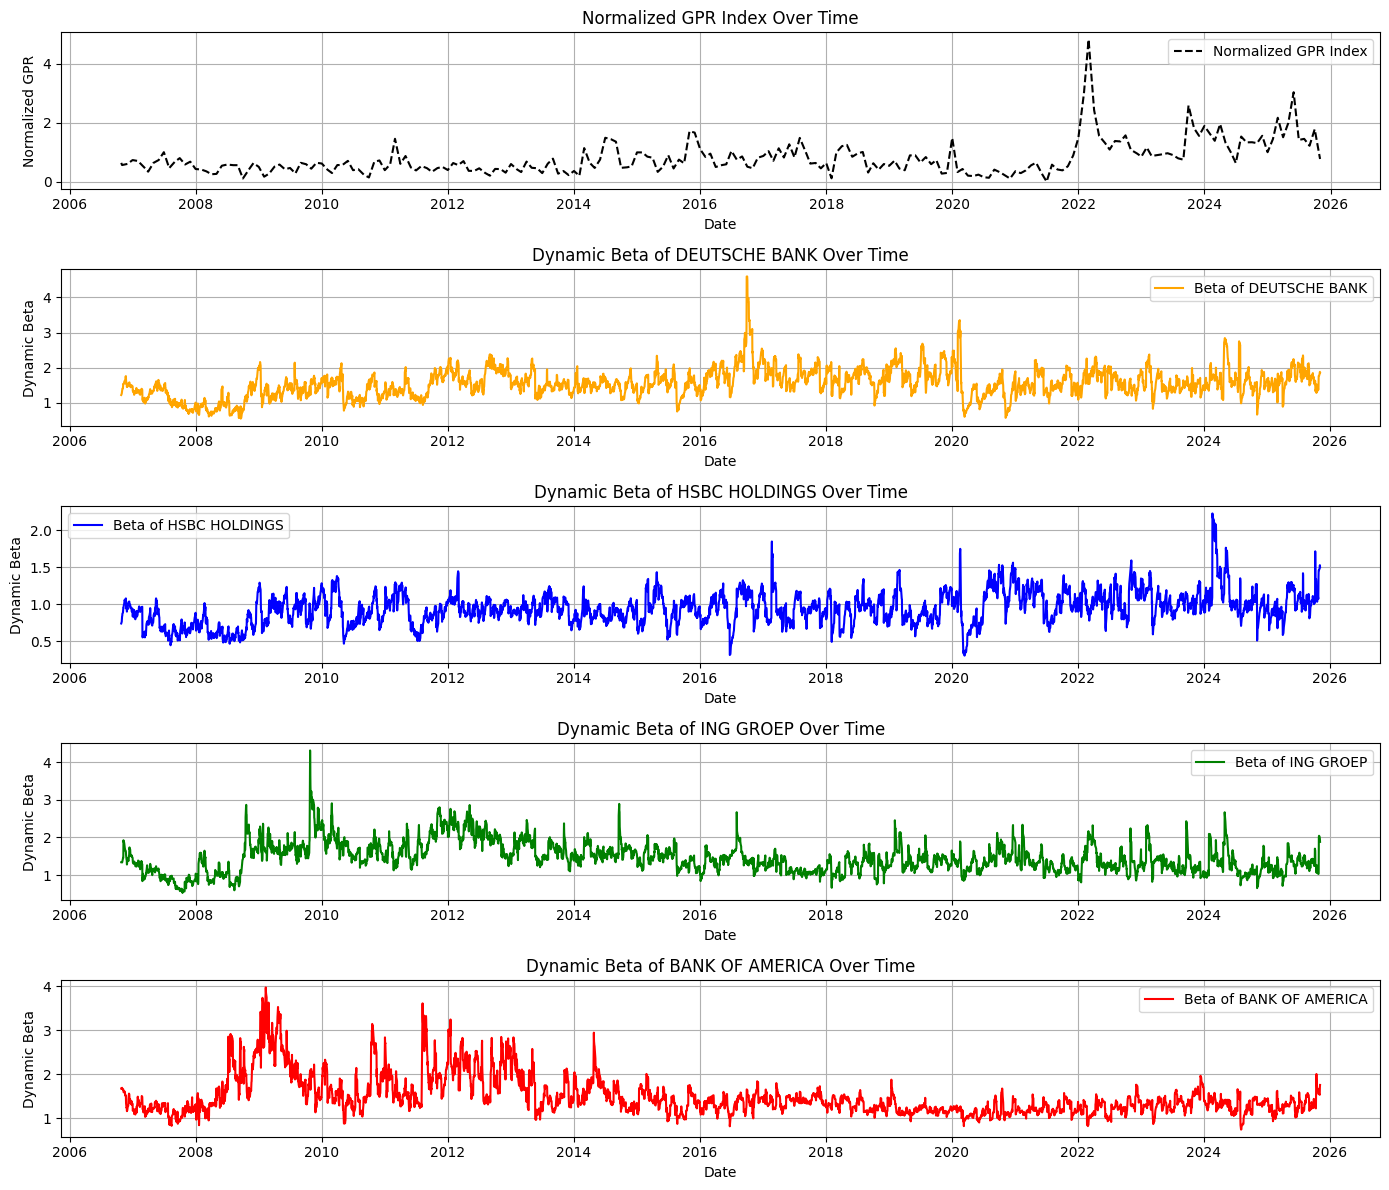

In [251]:
# Select the columns to plot selected bank betas
columns_to_plot = [7, 12, 18, 21]  # Adjusted for 0-based indexing
selected_banks = gsibs_beta_df.columns[columns_to_plot]

# Normalize the GPR index to match the range of the betas
gpr_data_normalized = (gpr_data['GPR'] - gpr_data['GPR'].min()) / (gpr_data['GPR'].max() - gpr_data['GPR'].min())
gpr_data_normalized *= (gsibs_beta_df.max().max() - gsibs_beta_df.min().min())

# Plot the GPR index and conditional betas over time
plt.figure(figsize=(14, 12))

# Plot the normalized GPR index at the top
plt.subplot(len(selected_banks) + 1, 1, 1)
plt.plot(gpr_data.index, gpr_data_normalized, label='Normalized GPR Index', color='black', linestyle='--')
plt.title('Normalized GPR Index Over Time')
plt.xlabel('Date')
plt.ylabel('Normalized GPR')
plt.legend()
plt.grid()

# Plot the conditional betas for the selected banks
for i, bank in enumerate(selected_banks, 2):  # Start from the second subplot
    plt.subplot(len(selected_banks) + 1, 1, i)
    plt.plot(gsibs_beta_df.index, gsibs_beta_df[bank], label=f'Beta of {bank}', color=['orange', 'blue', 'green', 'red'][i-2])
    plt.title(f'Dynamic Beta of {bank} Over Time')
    plt.xlabel('Date')
    plt.ylabel('Dynamic Beta')
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

In [252]:
# Calculate correlation between GPR index and conditional betas for selected banks
for bank in selected_banks:
    merged_data = pd.merge(gsibs_beta_df[[bank]], gpr_data, left_index=True, right_index=True, how='inner')
    corr = merged_data[bank].corr(merged_data['GPR'])
    print(f'Correlation between GPR index and beta of {bank}: {corr:.4f}')

Correlation between GPR index and beta of DEUTSCHE BANK: 0.1650
Correlation between GPR index and beta of HSBC HOLDINGS: 0.1857
Correlation between GPR index and beta of ING GROEP: -0.1546
Correlation between GPR index and beta of BANK OF AMERICA: -0.2172


### SRISK

First we want to match the dates of the market value of equity $E_t$ and the book value of the liabilities $D_t$ with the betas.

In [253]:
# Make sure the GSIBs_equity dataframe has the same indices as gsibs_beta_df
GSIBs_equity = GSIBs_equity.reindex(gsibs_beta_df.index)

# Validate alignment
assert GSIBs_equity.index.equals(gsibs_beta_df.index), "Indices are not aligned after reindexing!"
print("Indices are aligned after reindexing GSIBs_equity.")

Indices are aligned after reindexing GSIBs_equity.


In [254]:
# Adjust the date format for GSIBs_liabilities and GSIBs_assets to match date format of GSIBs_equity
def date_only_index(df, index_name="DATE"):
    df = df.copy()
    df.index = pd.to_datetime(df.index).normalize()  # strips hh:mm:ss and nanoseconds
    df.index.name = index_name
    return df

GSIBs_liabilities = date_only_index(GSIBs_liabilities, "PERIOD")
GSIBs_assets      = date_only_index(GSIBs_assets, "PERIOD")
OSIIs_liabilities = date_only_index(OSIIs_liabilities, "PERIOD")
OSIIs_assets      = date_only_index(OSIIs_assets, "PERIOD")

# Since quarters are repeats, take one value per year 
def to_yearly(df, how="last"):
    # Resample to year-end. 'last' keeps year-end snapshot.
    if how == "last":
        return df.resample("YE").last()
    elif how == "mean":
        return df.resample("YE").mean()
    else:
        raise ValueError("how must be 'last' or 'mean'")

GSIBs_liabilities = to_yearly(GSIBs_liabilities, how="last")
GSIBs_assets  = to_yearly(GSIBs_assets, how="last")
OSIIs_liabilities = to_yearly(OSIIs_liabilities, how="last")
OSIIs_assets  = to_yearly(OSIIs_assets, how="last")

# Replace 2025-12-31 with 2025-10-06 in the GSIBs_liabilities and GSIBs_assets dataframe since that is the last date in gsibs_beta_df and GSIBs_equity
GSIBs_liabilities.index = GSIBs_liabilities.index.to_series().replace(pd.Timestamp('2025-12-31'), pd.Timestamp('2025-10-06'))
GSIBs_assets.index      = GSIBs_assets.index.to_series().replace(pd.Timestamp('2025-12-31'), pd.Timestamp('2025-10-06'))

# Reverse the dataframes to have the most recent dates first
GSIBs_liabilities = GSIBs_liabilities.iloc[::-1]
GSIBs_assets = GSIBs_assets.iloc[::-1]
OSIIs_liabilities = OSIIs_liabilities.iloc[::-1]
OSIIs_assets = OSIIs_assets.iloc[::-1]

In [255]:
# Check the first few rows of the adjusted dataframes
print("Adjusted GSIBs_liabilities DataFrame (first 5 rows):")
print(GSIBs_liabilities.head())
print("Adjusted GSIBs_assets DataFrame (first 5 rows):")
print(GSIBs_assets.head())

Adjusted GSIBs_liabilities DataFrame (first 5 rows):


            ROYAL BANK OF CANADA  TORONTO DOMINION    UBS GROUP  \
PERIOD                                                            
2025-10-06                   NaN               NaN          NaN   
2024-12-31             2040062.0         1941654.0  1331766.240   
2023-12-31             1884786.0         1840957.0  1363976.850   
2022-12-31             1807572.0         1803952.0   959925.225   
2021-12-31             1605550.0         1626589.0   955141.248   

            BANK OF CHINA  CHINA CON.BANK  INDL&COML.BOC.  BANK OF COMMS.  \
PERIOD                                                                      
2025-10-06            NaN             NaN             NaN             NaN   
2024-12-31     32335607.0      37206699.0      44934163.0      13832212.0   
2023-12-31     29880150.0      35171516.0      41035539.0      13050481.0   
2022-12-31     26526049.0      31689615.0      36213948.0      12047746.0   
2021-12-31     24520638.0      27587505.0      32036583.0      1078

Now we want to reindex to the trading-day index from yearly, and interpolate by time by forward-filling

In [ ]:
target_idx = pd.to_datetime(gsibs_beta_df.index).normalize()
target_idx_asc = target_idx.sort_values()

common_cols = [c for c in gsibs_beta_df.columns
               if c in GSIBs_liabilities.columns and c in GSIBs_assets.columns]

def reindex_to_beta_and_ffill(df, target_idx_asc, cols):
    df2 = df.loc[:, cols].copy()

    # clean index + sort
    df2.index = pd.to_datetime(df2.index).normalize()
    df2 = df2.sort_index()

    # IMPORTANT: keep anchor dates even if not trading days
    union_idx = target_idx_asc.union(df2.index).sort_values()

    # forward-fill on the union, then take only beta dates
    out = df2.reindex(union_idx).ffill()
    out = out.reindex(target_idx_asc)

    # return aligned to the original beta index order (usually already sorted)
    return out.reindex(pd.to_datetime(gsibs_beta_df.index).normalize())

GSIBs_liabilities = reindex_to_beta_and_ffill(GSIBs_liabilities, target_idx_asc, common_cols)
GSIBs_assets      = reindex_to_beta_and_ffill(GSIBs_assets,      target_idx_asc, common_cols)

print("GSIBs_liabilities aligned:", GSIBs_liabilities.shape,
      "index matches beta:", GSIBs_liabilities.index.equals(pd.to_datetime(gsibs_beta_df.index).normalize()))
print("GSIBs_assets aligned:", GSIBs_assets.shape,
      "index matches beta:", GSIBs_assets.index.equals(pd.to_datetime(gsibs_beta_df.index).normalize()))

GSIBs_liabilities aligned: (4965, 27) index matches beta: True
GSIBs_assets aligned: (4965, 27) index matches beta: True


Now that all the dataframes are aligned and the liabilities and assets have been interpolated, we compute LRMES

In [275]:
# Approximate LRMES for G-SIBs using the conditional betas and a market decline of 40%
market_decline = -0.4

GSIBs_LRMES = 1 - np.exp(gsibs_beta_df * market_decline)

# Print the first 10 rows and 4 columns of the G-SIBs LRMES DataFrame
print("LRMES for G-SIBs (first 10 rows and 4 columns):")
print(GSIBs_LRMES.iloc[:5, :4])
# Print the last 10 rows and 4 columns of the G-SIBs LRMES DataFrame
print("LRMES for G-SIBs (last 10 rows and 4 columns):")
print(GSIBs_LRMES.iloc[-5:, :4])

LRMES for G-SIBs (first 10 rows and 4 columns):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA
DATE                                                                        
2025-11-06              0.241115          0.271293   0.434543       0.189102
2025-11-05              0.247045          0.276184   0.427782       0.188441
2025-11-04              0.248781          0.275683   0.386846       0.187647
2025-11-03              0.235578          0.250609   0.382688       0.187726
2025-10-31              0.222125          0.246651   0.378550       0.152328
LRMES for G-SIBs (last 10 rows and 4 columns):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA
DATE                                                                        
2006-11-02              0.234566          0.227247   0.433064       0.123571
2006-11-01              0.201337          0.202388   0.432169       0.123988
2006-10-31              0.191841          0.198071   0.428

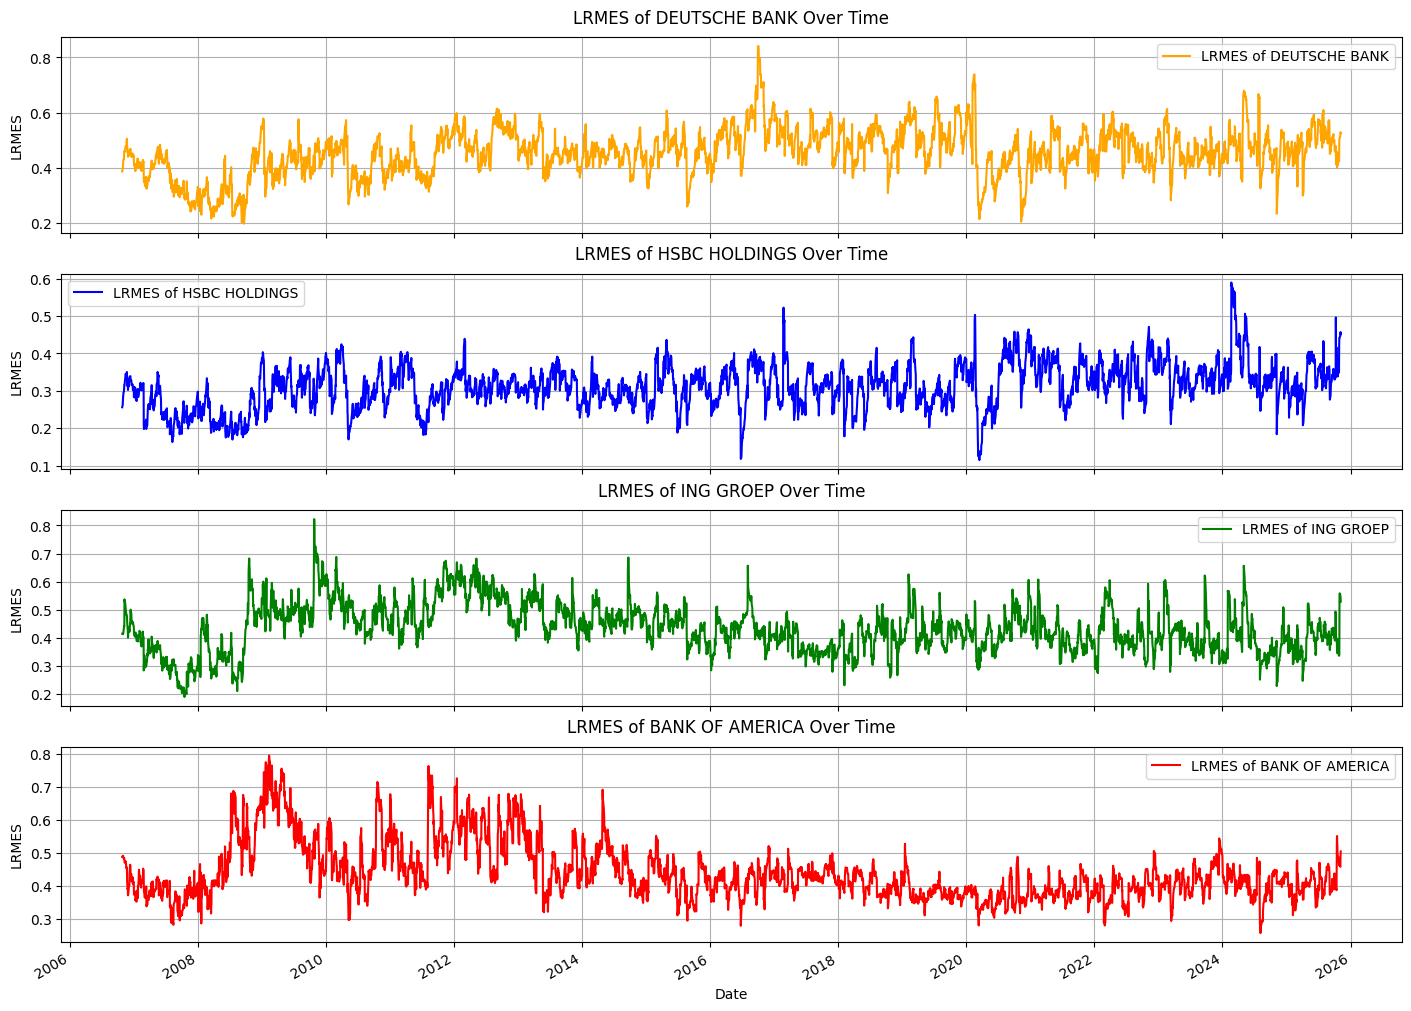

In [276]:
# Plot LRMES for selected G-SIBs (no overlap between titles and x-axes)
columns_to_plot = [7, 12, 18, 21]  # Adjusted for 0-based indexing
selected_banks = GSIBs_LRMES.columns[columns_to_plot]

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    sharex=True,
    figsize=(14, 10),
    constrained_layout=True,   # prevents title/xlabel overlap across subplots
)

colors = ['orange', 'blue', 'green', 'red']
for i, bank in enumerate(selected_banks):
    ax = axes[i]
    ax.plot(GSIBs_LRMES.index, GSIBs_LRMES[bank], label=f'LRMES of {bank}', color=colors[i])
    ax.set_title(f'LRMES of {bank} Over Time', pad=10)
    ax.set_ylabel('LRMES')
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel('Date')
fig.autofmt_xdate()  # improve date label spacing/rotation
plt.show()

Finally we are ready to apply the SRISK formula

In [277]:
# Set a capital ratio
k = 0.08

# Apply the SRISK formula, without max function because negative values are interesting as well for analysis with absorption capacity
GSIBs_SRISK = k * (GSIBs_liabilities + GSIBs_equity) - (1 - GSIBs_LRMES) * GSIBs_equity

# Print the first 10 rows and all columns of the G-SIBs SRISK DataFrame
print("SRISK for G-SIBs (first 10 rows and all columns):")
print(GSIBs_SRISK.iloc[:10, :])

SRISK for G-SIBs (first 10 rows and all columns):
            ROYAL BANK OF CANADA  TORONTO DOMINION     UBS GROUP  \
DATE                                                               
2025-11-06         -32567.954490      30381.693498  56610.153082   
2025-11-05         -31226.505176      30985.096528  55256.875738   
2025-11-04         -30498.615118      31205.199396  52132.000201   
2025-11-03         -36059.033869      24535.193240  51545.996519   
2025-10-31         -38259.988685      23784.567785  50941.546273   
2025-10-30         -37643.733287      24491.363978  51045.416348   
2025-10-29         -37377.129081      25053.939336  51161.664202   
2025-10-28         -53559.620040      20795.275455  49365.984918   
2025-10-27         -53160.573792      20423.110537  49361.679277   
2025-10-24         -50060.442635      22565.374371  50644.928044   

            BANK OF CHINA  CHINA CON.BANK  INDL&COML.BOC.  BANK OF COMMS.  \
DATE                                                    

Plot SRISK

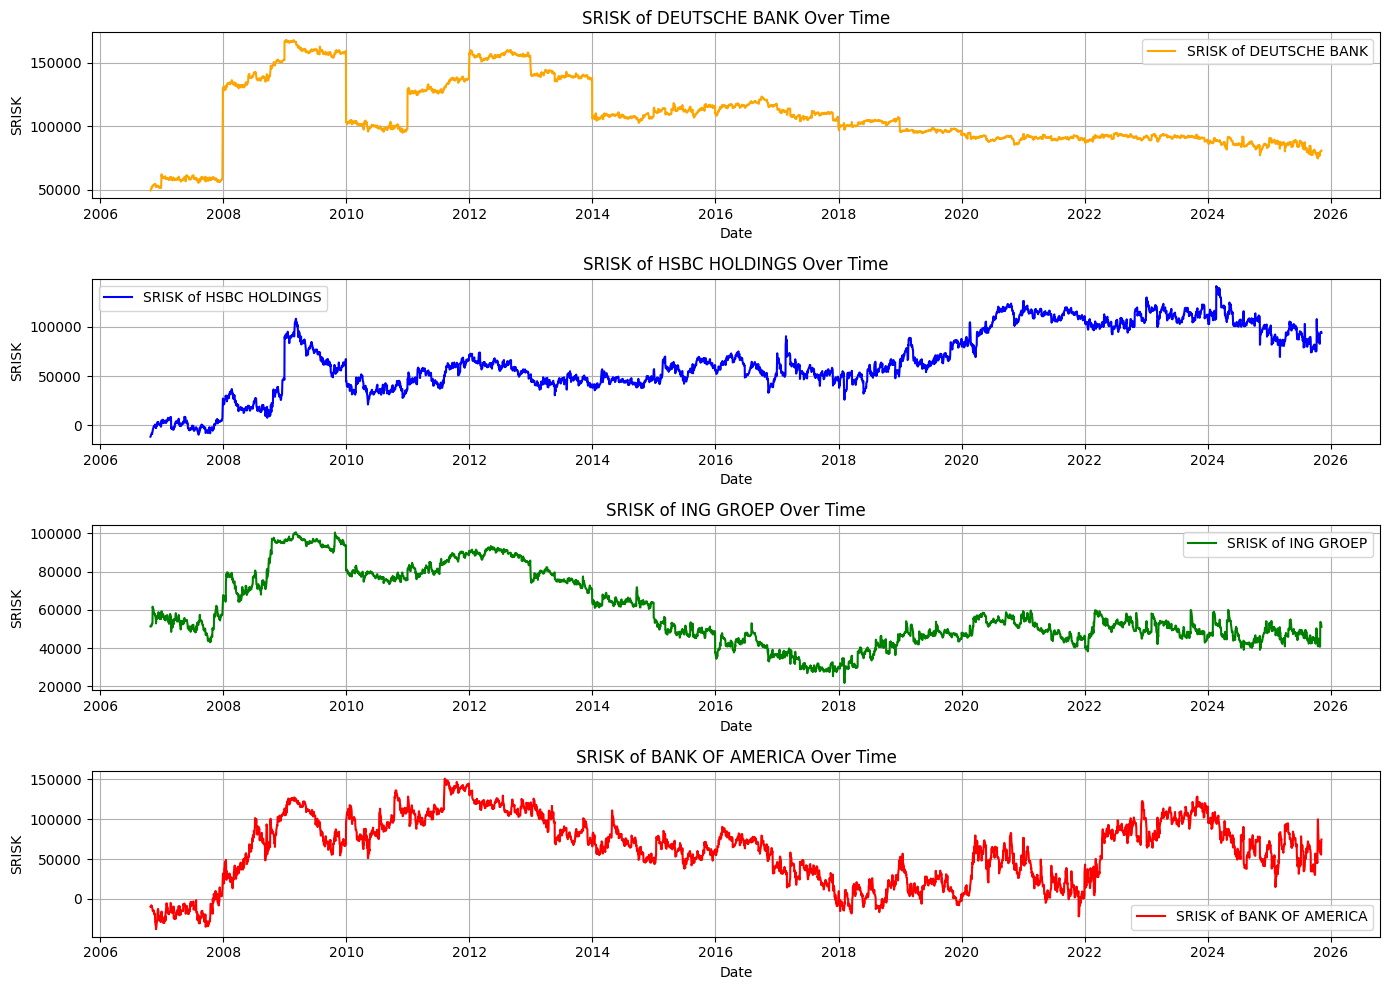

In [278]:
# Plot SRISK for selected G-SIBs
columns_to_plot = [7, 12, 18, 21]  # Adjusted for 0-based indexing
selected_banks = GSIBs_SRISK.columns[columns_to_plot]
plt.figure(figsize=(14, 10))
for i, bank in enumerate(selected_banks, 1):
    plt.subplot(4, 1, i)
    plt.plot(GSIBs_SRISK.index, GSIBs_SRISK[bank], label=f'SRISK of {bank}', color=['orange', 'blue', 'green', 'red'][i-1])
    plt.title(f'SRISK of {bank} Over Time')
    plt.xlabel('Date')
    plt.ylabel('SRISK')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

Compute a table of the SRISK in descending order for certain years

In [26]:
# Since the SRISK values are only different year-to-year, reindex to yearly frequency
GSIBs_SRISK_yearly = GSIBs_SRISK.resample('A').last()

# Convert date format to YYYY
GSIBs_SRISK_yearly.index = GSIBs_SRISK_yearly.index.to_period('Y').to_timestamp()

C:\Users\Asus\AppData\Local\Temp\ipykernel_14264\1137807162.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  GSIBs_SRISK_yearly = GSIBs_SRISK.resample('A').last()


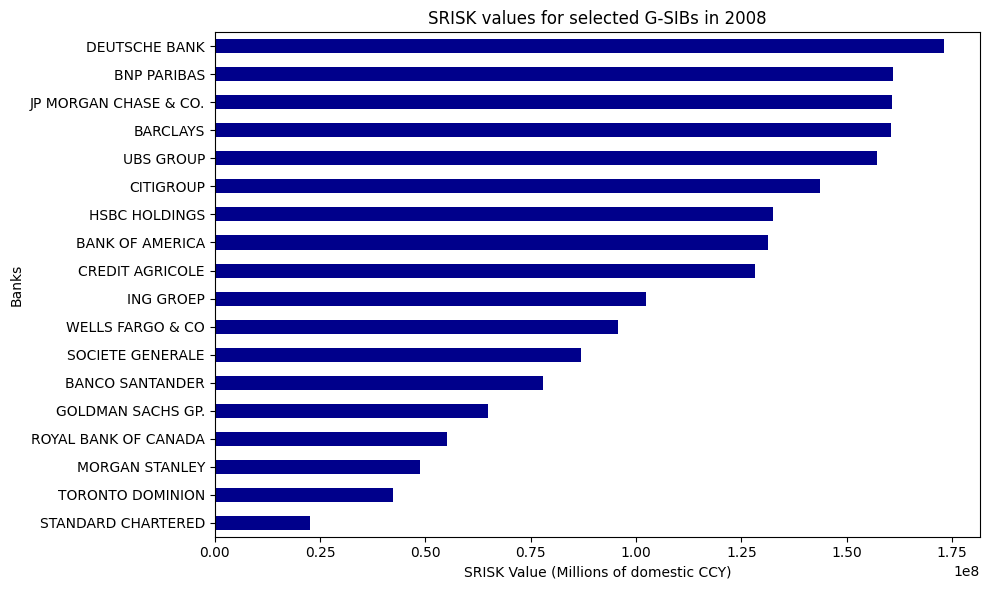

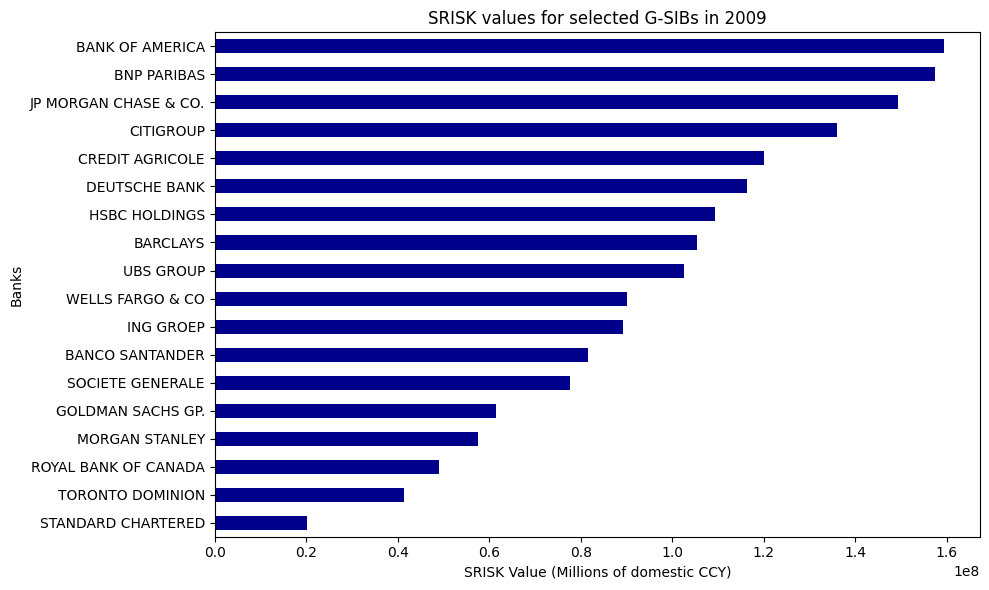

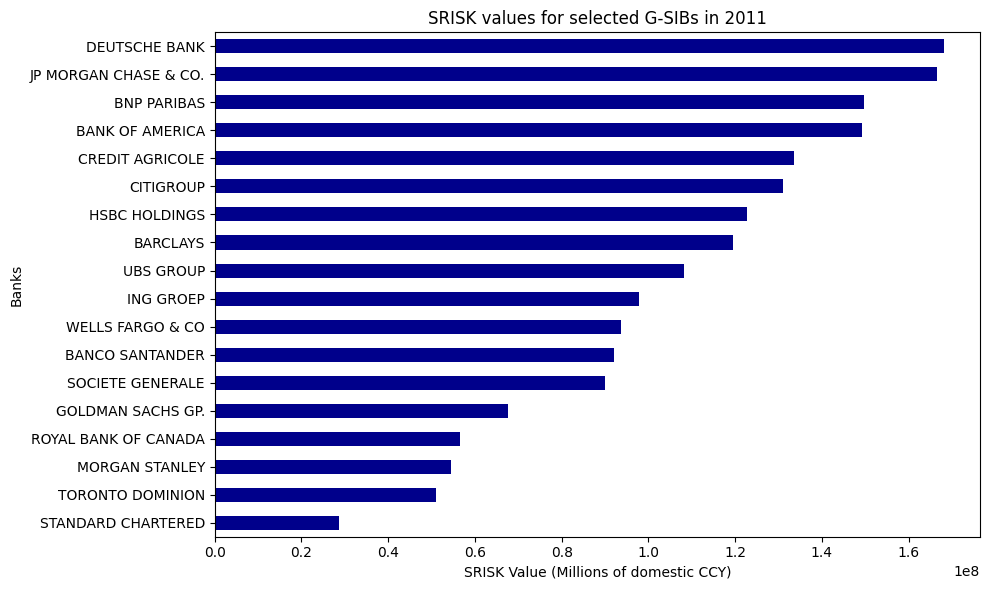

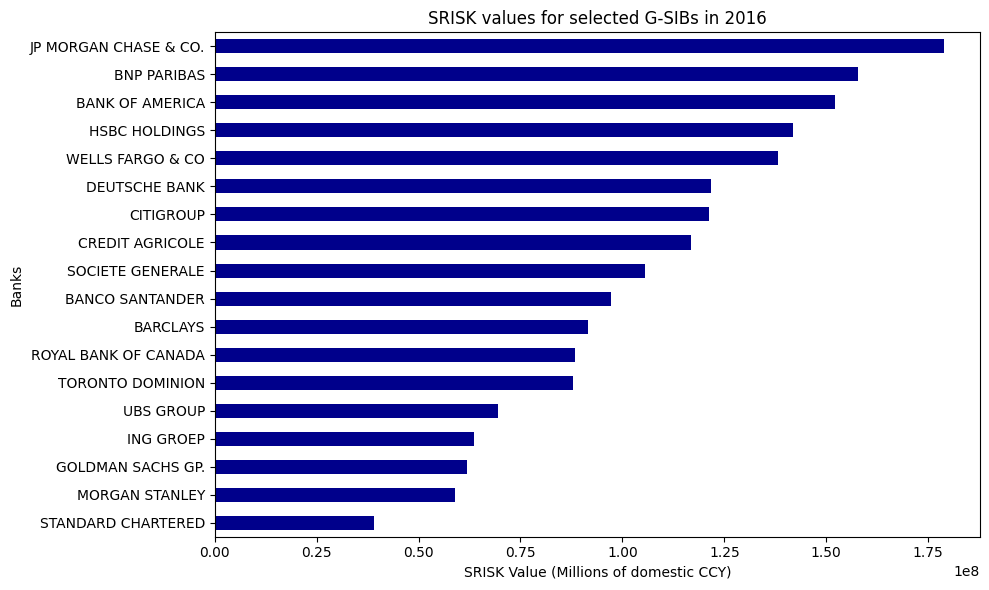

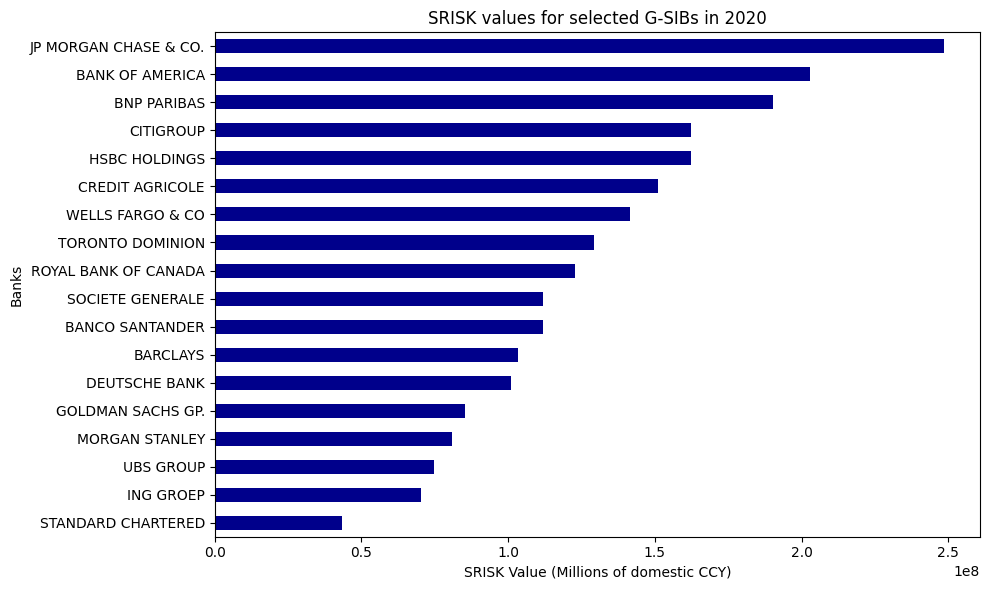

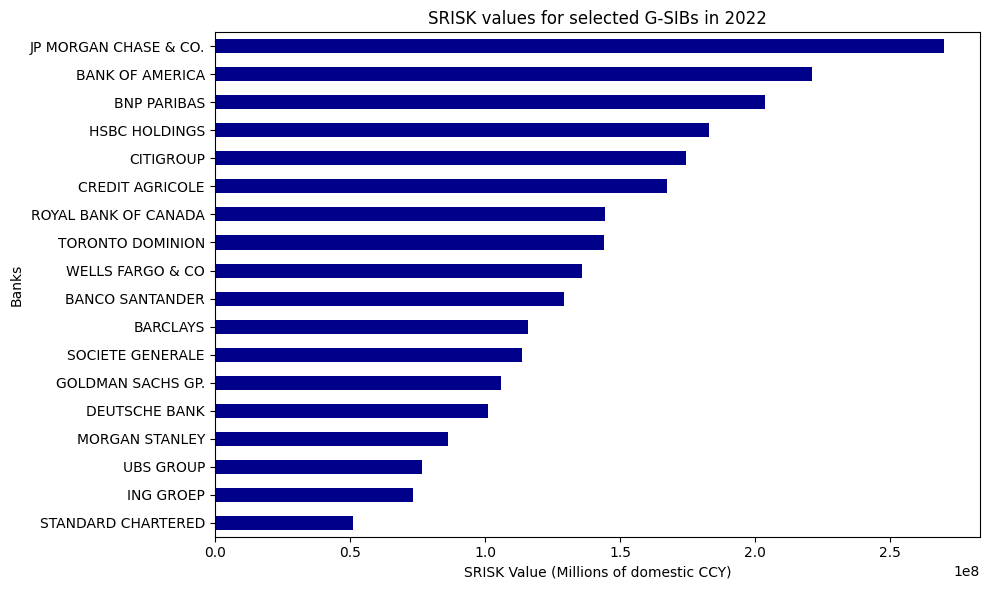

In [27]:
# Set pandas display option to avoid scientific notation
pd.options.display.float_format = '{:.2f}'.format

# Define the years of interest
years_of_interest = [2008, 2009, 2011, 2016, 2020, 2022]

# Define the banks to exclude
excluded_banks = ['STATE STREET', 'BANK OF NEW YORK MELLON', 'BANK OF COMMS.', 
                  'BANK OF CHINA', 'CHINA CON.BANK', 'INDL&COML.BOC.']

# Iterate over the years and create horizontal bar charts for each
for year in years_of_interest:
    year_start = pd.Timestamp(f'{year}-01-01')
    if year_start in GSIBs_SRISK_yearly.index:
        srisk_for_year = GSIBs_SRISK_yearly.loc[year_start]
        
        # Exclude the specified banks
        srisk_for_year = srisk_for_year.drop(labels=excluded_banks, errors='ignore')
        
        # Exclude anything over a billion for readability
        filtered_srisk = srisk_for_year[srisk_for_year < 1e9]
        
        # Sort the SRISK values in ascending order
        sorted_srisk = filtered_srisk.sort_values(ascending=False)
        
        # Plot the horizontal bar chart
        plt.figure(figsize=(10, 6))
        sorted_srisk.plot(kind='barh', color='darkblue')
        plt.gca().invert_yaxis()  # Reverse the order of the y-axis
        plt.title(f"SRISK values for selected G-SIBs in {year}")
        plt.xlabel("SRISK Value (Millions of domestic CCY)")
        plt.ylabel("Banks")
        plt.tight_layout()
        plt.show()
    else:
        print(f"No SRISK data available for the year {year}.\n")

# Reset pandas display option to default
pd.reset_option('display.float_format')